# Margin Calculations for Box in Sphere Variations

## Setup

### Imports

In [1]:
import logging
from math import isnan

import pytest

# Local functions and classes
from types_and_classes import *
from utilities import *
from contour_plotting import *
from debug_tools import *
from structure_set import *
from relations import *
from region_slice import empty_structure
from contour_plotting import plot_roi_slice


INFO:metrics.base:Registered calculator: minimum_margins (ContainmentMarginsCalculator)
INFO:metrics.base:Registered calculator: maximum_margin (MaximumMarginCalculator)
INFO:metrics.base:Registered calculator: minimum_distance (MinimumDistanceCalculator)


### Global Settings

In [2]:
%matplotlib inline

## Margin Calculations

### Box embedded and centered in sphere
- Equal orthogonal margins


#### Minimum Horizontal Margin on a Plane**

<img src="../../Images/Box_in_Circle/Ideal_Orthogonal_Margin.png" alt="Ideal Orthogonal Margin" style="width: 8cm;">

$M_x = \sqrt{r^2 - (h/2)^2} - w/2$

- but this is in 3D
- the radius on the plane is not the sphere radius, but the circle radius on that slice.

- The sphere equation is:
$X^2 + Y^2 + Z^2 = r^2$
- The equation of the circle on the plane is:
$X^2 + Y^2 = r^2 - SliceIndex^2 = r^2 - (w/2)^2$

- The Circle radius is $r_i = \sqrt{r^2 - (w/2)^2}$
- The final equation is 
$M_x = \sqrt{r_i^2 - (h/2)^2} - w/2$<br>
$M_x = \sqrt{r^2 - (w/2)^2 - (h/2)^2} - w/2$<br>

-----------
**Numeric Value**
$h=4$, $w=4$, $r=4$

$M_x = \sqrt{4^2 - (2)^2 - (2)^2} - 2 = \sqrt{16-4-4} - 2 = \sqrt{8} - 2 = 0.83$


#### Slice Based Z Margin
- in the ideal case the Z Margin would be the same as the X Margin
- Because the calculations are slice based some approximations will come into play

<img src="../../Images/Box_in_Circle/Slice_Based_Orthogonal_Margin.png" alt="Slice Based Orthogonal Margin" style="width: 8cm;">

- Find the slice where the circle overlaps the square
- The widest part of the square is at its corners
- The radius is less than $\sqrt{2(w/2)^2}$

- The radius of the circle on a given Z plane is:
$r_i^2 = r^2 - Z^2$
- The first Slice Index where $r_i$ will be obtained from:
$Z_i = \sqrt{r^2 - 2(w/2)^2}$
- $Z_i$ is then rounded up to the next nearest Slice Index
- The Margin is the difference between the *reference* Slice Index of the box
and the first *test* Slice Index where the circle overlaps the square.

-----------
**Numeric Value**

$h=4$, $w=4$, $r=4$ 

`slice_spacing = 0.1`

$Z_i = \sqrt{4^2 - 2(2)^2} - 2 = \sqrt{16-8} = \sqrt{8} = 2.83$
- The next nearest Slice Index *rounding up* is 0.9

- $M_z = 2.9 -2.0 = 0.9$


#### Minimum Margin

<img src="../../Images/Box_in_Circle/Ideal_Minimum_Margin.png" alt="Ideal Minimum Margin" style="width: 8cm;">

- The overall 3D Minimum Margin will be the distance between the corner of the box and the sphere
- The distance from the centre to a corner of the box is:
$d = \sqrt{(h/2)^2 + (w/2)^2 + (w/2)^2}$

- The Minimum Margin will be the difference between the distance to the box corner and the radius of the sphere.

Minimum Margin = $M_m = r - \sqrt{(h/2)^2 + (w/2)^2 + (w/2)^2}$

-----------
**Numeric Value**

$h=4$, $w=4$, $r=4$ 

$M_m = 4 - \sqrt{2^2 + 2^2 + 2^2} = 4 - \sqrt{12} = 4 - 3.46 = 0.53$


#### Slice Based Minimum Margin

<img src="../../Images/Box_in_Circle/Slice_Based_Minimum_Margin.png" alt="Slice Based Minimum Margin" style="width: 8cm;">

- Calculate horizontal distance by slice
- Convert horizontal distance into 3D distance by:
$d_{3D} = \sqrt{d^2 + \Delta z^2}$

-------
***Something is Wrong with this calculation or the assumption***
- Minimum Margin expected to occur at an angle of $45\degree$ 
- $r^2 = x^2 + y^2 + z^2$ 
- At $45\degree$ $z^2 = x^2 +y^2$
- $r^2 = 2z^2 \to z = \sqrt{r^2/2}$
- For $r=4$ $z = \sqrt{8} = 2.83$
- *Should get slice 2.3*


#### Tests of calculations

##### Make Structures

In [3]:
tolerance = 0.1
slice_spacing = 0.1

# Body structure defines slices in use
body = make_vertical_cylinder(roi_num=0, radius=20, length=10, offset_z=0,
                            spacing=slice_spacing)
# box centered within the sphere
outer_sphere = make_sphere(roi_num=1, radius=4, spacing=slice_spacing, num_points=300)
inner_cube = make_box(roi_num=2, width=4, offset_x=0, offset_y=0, offset_z=0,
                        spacing=slice_spacing)
# combine the contours
slice_data = outer_sphere + inner_cube + body

embedded_box_structures = StructureSet(slice_data)
structure_a = embedded_box_structures.structures[1]
structure_b = embedded_box_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nOuter Sphere {relation_type.label} Inner Cube')

INFO:structure_set:Adding structure Structure_0 (0)
INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



Outer Sphere Contains Inner Cube


##### Boundary slices

In [4]:
slices = embedded_box_structures.slice_sequence.sequence
print(slices[~slices.Original])
#slices

           ThisSlice  NextSlice  PreviousSlice  Original
ThisSlice                                               
-5.025        -5.025       -5.0            NaN     False
-4.050        -4.050       -4.0           -4.1     False
-2.050        -2.050       -2.0           -2.1     False
 2.050         2.050        2.1            2.0     False
 4.050         4.050        4.1            4.0     False
 5.025         5.025        NaN            5.0     False


##### Example slice

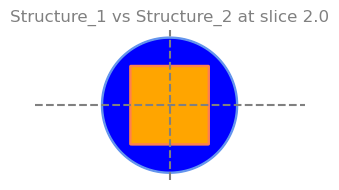

In [5]:
# Create figure and plot
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
slice_idx = 2.0
plot_roi_slice(embedded_box_structures, slice_index=slice_idx,
               roi_list=[1, 2],
               add_axis=True, axes=ax, tolerance=tolerance,
               plot_mode='relationship', show_legend=False)
plt.tight_layout()
plt.show()

#### Horizontal X Margin

In [6]:
a_slice_poly = structure_a.get_slice(slice_idx).regions['1A'].boundary
b_slice_poly = structure_b.get_slice(slice_idx).regions['2A'].boundary
b_slice_points = shapely.get_coordinates(b_slice_poly)
ortho_line = shapely.LineString([b_slice_points[0], [b_slice_points[0][0], b_slice_points[0][1] + 10]])
ortho_line.intersection(a_slice_poly).distance(shapely.Point(b_slice_points[0]))

0.8286271186440679

##### Vertical Margin

In [7]:
reference_slice = 2.0
b_slice_poly = structure_b.get_slice(reference_slice).regions['2A']
test_slice = 2.8
a_slice_poly = structure_a.get_slice(test_slice).regions['1A']
r = DE27IM(a_slice_poly,b_slice_poly)
r.identify_relation()

RelationshipType(CONTAINS)

In [8]:
test_slice = 2.9
a_slice_poly = structure_a.get_slice(test_slice).regions['1A']
r = DE27IM(a_slice_poly,b_slice_poly)
r.identify_relation()

RelationshipType(OVERLAPS)

##### Minimum 3D Margin

In [9]:
#2D Margin as initial reference
reference_slice = 2.0
b_slice_poly = structure_b.get_slice(reference_slice).regions['2A']
a_slice_poly = structure_a.get_slice(reference_slice).regions['1A']
total_dist = a_slice_poly.boundary.distance(b_slice_poly.boundary)
print(f'Total distance at slice {reference_slice}: {total_dist:.2f}')
min_distance = total_dist

# Iterate through slices and calculate distances
test_slices = list(slices.loc[slices.Original,'ThisSlice'])
for test_slice in test_slices:
    v_dist = abs(test_slice - reference_slice)
    if v_dist > min_distance:
        # If the vertical distance alone exceeds the current minimum, skip this slice
        continue
    # Calculate horizontal distance at this slice
    a_slice_poly = structure_a.get_slice(test_slice).regions['1A']
    h_dist = a_slice_poly.boundary.distance(b_slice_poly.boundary)
    # Combine horizontal and vertical distances to get total 3D distance
    total_distance = (h_dist**2 + v_dist**2)**0.5
    if total_distance < min_distance:
        # Update minimum distance if this distance is closer
        min_distance = total_distance
    print(
        f'Slice {test_slice:.1f}: Horizontal distance: {h_dist:.2f}, '
        f'Vertical distance: {v_dist:.2f}, Total distance: {total_distance:.2f}'
    )
print(f'Minimum distance: {min_distance:.2f}')

Total distance at slice 2.0: 0.64
Slice 1.4: Horizontal distance: 0.92, Vertical distance: 0.60, Total distance: 1.10
Slice 1.5: Horizontal distance: 0.88, Vertical distance: 0.50, Total distance: 1.01
Slice 1.6: Horizontal distance: 0.84, Vertical distance: 0.40, Total distance: 0.93
Slice 1.7: Horizontal distance: 0.79, Vertical distance: 0.30, Total distance: 0.85
Slice 1.8: Horizontal distance: 0.74, Vertical distance: 0.20, Total distance: 0.77
Slice 1.9: Horizontal distance: 0.69, Vertical distance: 0.10, Total distance: 0.70
Slice 2.0: Horizontal distance: 0.64, Vertical distance: 0.00, Total distance: 0.64
Slice 2.1: Horizontal distance: 0.58, Vertical distance: 0.10, Total distance: 0.58
Slice 2.2: Horizontal distance: 0.51, Vertical distance: 0.20, Total distance: 0.55
Slice 2.3: Horizontal distance: 0.44, Vertical distance: 0.30, Total distance: 0.54
Slice 2.4: Horizontal distance: 0.37, Vertical distance: 0.40, Total distance: 0.55
Slice 2.5: Horizontal distance: 0.29, Vert

### Pair of box embedded and centered in sphere offset horizontally from each other

**Minimum Horizontal Margin on a Plane**

- If the box is still a cube the previous equations should still hold
- $M_x = \sqrt{r^2 - (w/2)^2 - (h/2)^2} - w/2$

**Numeric Value**

$h=2$, $w=2$, $r=4$

$M_x = \sqrt{4^2 - 1 - 1} - 2 = \sqrt{16-2} - 1 = \sqrt{14} - 1 = 2.74$

-----------

**Minimum Margin**

- Minimum Margin = $M_m = r - \sqrt{(h/2)^2 + (w/2)^2 + (w/2)^2}$

**Numeric Value**

$h=2$, $w=2$, $r=4$ 

$M_m = 4 - \sqrt{1^2 + 1^2 + 1^2} = 4 - \sqrt{3} = 4 - 1.73 = 2.27$

-----------


##### Make Structures

In [10]:
tolerance = 0.1
slice_spacing = 0.1
# laterally shifted box in sphere
left_outer_sphere = make_sphere(roi_num=1, radius=4, spacing=slice_spacing, 
                                offset_x=-5, offset_y=0, offset_z=0,
                                num_points=300)
left_inner_cube = make_box(roi_num=2, width=4,
                           spacing=slice_spacing, 
                           offset_x=-5, offset_y=0, offset_z=0)
# laterally shifted box in sphere
right_outer_sphere = make_sphere(roi_num=1, radius=4, spacing=slice_spacing, 
                                offset_x=5, offset_y=0, offset_z=0,
                                num_points=300)
# Smaller box inside same sized sphere
right_inner_cube = make_box(roi_num=2, width=2, spacing=slice_spacing,
                           offset_x=5, offset_y=0, offset_z=0)
# combine the contours
slice_data = left_outer_sphere + left_inner_cube + right_outer_sphere + right_inner_cube

dual_box_in_sphere_structures = StructureSet(slice_data)
structure_a = dual_box_in_sphere_structures.structures[1]
structure_b = dual_box_in_sphere_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nOuter Sphere {relation_type.label} Inner Cube')

INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 2 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



Outer Sphere Contains Inner Cube


##### Boundary slices

In [11]:
slices = dual_box_in_sphere_structures.slice_sequence.sequence
print(slices[~slices.Original])
#slices

           ThisSlice  NextSlice  PreviousSlice  Original
ThisSlice                                               
-4.025        -4.025       -4.0            NaN     False
-2.050        -2.050       -2.0           -2.1     False
-1.050        -1.050       -1.0           -1.1     False
 1.050         1.050        1.1            1.0     False
 2.050         2.050        2.1            2.0     False
 4.025         4.025        NaN            4.0     False


##### Example slice

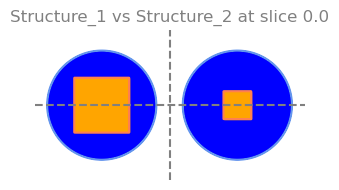

In [12]:
# Create figure and plot
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
slice_idx = 0.0
plot_roi_slice(dual_box_in_sphere_structures, slice_index=slice_idx,
               roi_list=[1, 2],
               add_axis=True, axes=ax, tolerance=tolerance,
               plot_mode='relationship', show_legend=False)
plt.tight_layout()
plt.show()

In [13]:
slice_idx = 0.0
a1_slice_poly = structure_a.get_slice(slice_idx).regions['1A']
b1_slice_poly = structure_b.get_slice(slice_idx).regions['2A']
print(f'Region 1A and 2A relation: {DE27IM(a1_slice_poly,b1_slice_poly).identify_relation()}')
a2_slice_poly = structure_a.get_slice(slice_idx).regions['1B']
b2_slice_poly = structure_b.get_slice(slice_idx).regions['2B']
print(f'Region 1B and 2B relation: {DE27IM(a2_slice_poly,b2_slice_poly).identify_relation()}')
print(f'Region 1A and 2B relation: {DE27IM(a1_slice_poly,b2_slice_poly).identify_relation()}')

Region 1A and 2A relation: Relationship: Contains
Region 1B and 2B relation: Relationship: Contains
Region 1A and 2B relation: Relationship: is Disjoint from


In [14]:
slice_idx = 2.0
a_slice_poly = structure_a.get_slice(slice_idx).regions['1A'].boundary
b_slice_poly = structure_b.get_slice(slice_idx).regions['2A'].boundary
b_slice_points = shapely.get_coordinates(b_slice_poly)
ortho_line = shapely.LineString([b_slice_points[0], [b_slice_points[0][0], b_slice_points[0][1] + 10]])
ortho_line.intersection(a_slice_poly).distance(shapely.Point(b_slice_points[0]))

0.8286271186440679

In [15]:
slice_idx = 1.0
a_slice_poly = structure_a.get_slice(slice_idx).regions['1B'].boundary
b_slice_poly = structure_b.get_slice(slice_idx).regions['2B'].boundary
b_slice_points = shapely.get_coordinates(b_slice_poly)
ortho_line = shapely.LineString([b_slice_points[0], [b_slice_points[0][0], b_slice_points[0][1] + 10]])
ortho_line.intersection(a_slice_poly).distance(shapely.Point(b_slice_points[0]))

2.7411645569620253

##### Vertical Margin

In [16]:
reference_slice = 1.0
b_slice_poly = structure_b.get_slice(reference_slice).regions['2B']
a_slice_poly = structure_a.get_slice(reference_slice).regions['1B']
starting_relation = DE27IM(a_slice_poly,b_slice_poly).identify_relation()
print(f'Relationship on slice {reference_slice}: {starting_relation}')

# Iterate through slices and calculate distances
test_slices_slct = (slices.ThisSlice > reference_slice) & (slices.Original)
test_slices = list(slices.loc[test_slices_slct,'ThisSlice'])

for test_slice in test_slices:
    a_slice_poly = structure_a.get_slice(test_slice).regions['1B']
    test_relation = DE27IM(a_slice_poly,b_slice_poly).identify_relation()
    if test_relation == starting_relation:
        continue
    print(f'Relationship on slice {test_slice}: {test_relation}')
    print(f'Vertical Margin = {test_slice - reference_slice}')
    break


Relationship on slice 1.0: Relationship: Contains
Relationship on slice 3.8: Relationship: Overlaps with
Vertical Margin = 2.8


##### Minimum 3D Margin

In [17]:
#2D Margin as initial reference
reference_slice = 1.0
b_slice_poly = structure_b.get_slice(reference_slice).regions['2B']
a_slice_poly = structure_a.get_slice(reference_slice).regions['1B']
total_dist = a_slice_poly.boundary.distance(b_slice_poly.boundary)
print(f'Total distance at slice {reference_slice}: {total_dist:.2f}')
min_distance = total_dist

# Iterate through slices and calculate distances
test_slices = list(slices.loc[slices.Original,'ThisSlice'])
for test_slice in test_slices:
    v_dist = abs(test_slice - reference_slice)
    if v_dist > min_distance:
        # If the vertical distance alone exceeds the current minimum, skip this slice
        continue
    # Calculate horizontal distance at this slice
    a_slice_poly = structure_a.get_slice(test_slice).regions['1B']
    h_dist = a_slice_poly.boundary.distance(b_slice_poly.boundary)
    # Combine horizontal and vertical distances to get total 3D distance
    total_distance = (h_dist**2 + v_dist**2)**0.5
    if total_distance < min_distance:
        # Update minimum distance if this distance is closer
        min_distance = total_distance
        print(f'Slice {test_slice:.1f}: Horizontal distance: {h_dist:.2f}, '
              f'Vertical distance: {v_dist:.2f}, Total distance: {total_distance:.2f}'
              )
print(f'Minimum distance: {min_distance:.2f}')

Total distance at slice 1.0: 2.46
Slice 1.1: Horizontal distance: 2.43, Vertical distance: 0.10, Total distance: 2.43
Slice 1.2: Horizontal distance: 2.40, Vertical distance: 0.20, Total distance: 2.41
Slice 1.3: Horizontal distance: 2.37, Vertical distance: 0.30, Total distance: 2.39
Slice 1.4: Horizontal distance: 2.33, Vertical distance: 0.40, Total distance: 2.37
Slice 1.5: Horizontal distance: 2.29, Vertical distance: 0.50, Total distance: 2.35
Slice 1.6: Horizontal distance: 2.25, Vertical distance: 0.60, Total distance: 2.33
Slice 1.7: Horizontal distance: 2.21, Vertical distance: 0.70, Total distance: 2.31
Slice 1.8: Horizontal distance: 2.16, Vertical distance: 0.80, Total distance: 2.30
Slice 1.9: Horizontal distance: 2.11, Vertical distance: 0.90, Total distance: 2.29
Slice 2.0: Horizontal distance: 2.05, Vertical distance: 1.00, Total distance: 2.28
Slice 2.1: Horizontal distance: 1.99, Vertical distance: 1.10, Total distance: 2.27
Slice 2.2: Horizontal distance: 1.93, Vert

### Sphere with two different sized boxes embedded

- Sphere with radius 4
- Left box 1x4x4 centred on -1.5,0,0
- Right box 2x2x2 centred on 2.5,0,0

- The Margins from the Left Box should be the same as those from the 4x4x4 centred cube:

**Minimum Orthogonal Margins**

- $M_{x_{neg}} = 0.83$
($M_{x_{pos}}$ will be defined by the Right Box)
- $M_z = 0.9$ 
(the next nearest Slice Index *rounding up*)

**Minimum Margin**
- For the Left Box this will be 
$M_m = 0.53$


- The sphere equation is:
$X^2 + Y^2 + Z^2 = r^2$
- The equation of the circle on the plane at the top of the Right Box is:
$X^2 + Y^2 = r^2 - (h_R/2)^2$

**Numeric Value**

$h=2$, $r=4$ $\to X^2 + Y^2 = 4^2 - (2/2)^2 = 16 - 1 \to r = \sqrt{15}$

**Minimum Horizontal Margin on a Plane**

$M_x = \sqrt{r^2 - (h/2)^2} - w/2 - \Delta x$

**Numeric Value**

$h=2$, $w=2$, $r=4$ $\to M_x = \sqrt{15 - (2/2)^2} - 2/2 - 2.5 = \sqrt{14} - 3.5 = 0.24$ 

- Due to the proximity to the surface of the sphere the **Minimum Margin** will be equal to the Horizontal X Margin

**Minimum Vertical Margin**
- This will occur where the sphere begins to overlap the box
- This will occur when the radius of the sphere is less than or equal to:
$\sqrt{(\Delta x + w/2)^2 + (l/2)^2}$
- $X^2 + Y^2 + Z^2 = \Delta x + w/2)^2 + (h/2)^2$
- Slice Index is Z:
$Z^2 = \Delta x + w/2)^2 + (l/2)^2$
- The vertical margin is:
$Z - h/2$
**Numeric Value**

$h=2$, $l=2$, $w=2$, $r=4$ $\to M_z = \sqrt{2.5 + 2/2)^2 + (2/2)^2} - 2/2 = \sqrt{13.25} - 1 = 2.64$ 

- Rounding to nearest slice gives $M_z = 2.7$

##### Make Structures

In [18]:
tolerance = 0.1
slice_spacing = 0.1
# laterally shifted box in sphere
outer_sphere = make_sphere(roi_num=1, radius=4, spacing=slice_spacing, 
                                offset_x=0, offset_y=0, offset_z=0,
                                num_points=300)
# laterally shifted boxes in sphere
left_inner_box = make_box(roi_num=2, width=1, length=4, height=4,
                           spacing=slice_spacing, 
                           offset_x=-1.5, offset_y=0, offset_z=0)
right_inner_box = make_box(roi_num=2, width=2, length=2, height=2, spacing=slice_spacing,
                           offset_x=2.5, offset_y=0, offset_z=0)
# combine the contours
slice_data = outer_sphere + left_inner_box + right_inner_box

dual_box_in_sphere_structures = StructureSet(slice_data)
structure_a = dual_box_in_sphere_structures.structures[1]
structure_b = dual_box_in_sphere_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nOuter Sphere {relation_type.label} Inner Cube')

INFO:structure_set:Adding structure Structure_1 (1)


INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 2 structures
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



Outer Sphere Contains Inner Cube


##### Boundary slices

In [19]:
slices = dual_box_in_sphere_structures.slice_sequence.sequence
print(slices[~slices.Original])
#slices

           ThisSlice  NextSlice  PreviousSlice  Original
ThisSlice                                               
-4.025        -4.025       -4.0            NaN     False
-2.050        -2.050       -2.0           -2.1     False
-1.050        -1.050       -1.0           -1.1     False
 1.050         1.050        1.1            1.0     False
 2.050         2.050        2.1            2.0     False
 4.025         4.025        NaN            4.0     False


##### Example slice

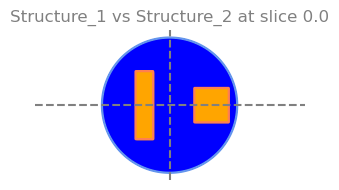

In [20]:
# Create figure and plot
fig, ax = plt.subplots(1, 1, figsize=(3, 2))
slice_idx = 0.0
plot_roi_slice(dual_box_in_sphere_structures, slice_index=slice_idx,
               roi_list=[1, 2],
               add_axis=True, axes=ax, tolerance=tolerance,
               plot_mode='relationship', show_legend=False)
plt.tight_layout()
plt.show()

In [29]:
slice_idx = 0.0
a1_slice_poly = structure_a.get_slice(slice_idx).regions['1A']
b1_slice_poly = structure_b.get_slice(slice_idx).regions['2A']
print(f'Region 1A and 2A relation: {DE27IM(a1_slice_poly,b1_slice_poly).identify_relation()}')
b2_slice_poly = structure_b.get_slice(slice_idx).regions['2B']
print(f'Region 1A and 2B relation: {DE27IM(a1_slice_poly,b2_slice_poly).identify_relation()}')

Region 1A and 2A relation: Relationship: Contains
Region 1A and 2B relation: Relationship: Contains


In [28]:
slice_idx = 1.0
a_slice_poly = structure_a.get_slice(slice_idx).regions['1A'].boundary
b_slice_poly = structure_b.get_slice(slice_idx).regions['2A'].boundary
b_slice_points = shapely.get_coordinates(b_slice_poly)
ortho_line = shapely.LineString([b_slice_points[0], [b_slice_points[0][0], b_slice_points[0][1] + 10]])
ortho_line.intersection(a_slice_poly).distance(shapely.Point(b_slice_points[0]))

1.7411645569620253

In [24]:
slice_idx = 1.0
a_slice_poly = structure_a.get_slice(slice_idx).regions['1A'].boundary
b_slice_poly = structure_b.get_slice(slice_idx).regions['2B'].boundary
b_slice_points = shapely.get_coordinates(b_slice_poly)
ortho_line = shapely.LineString([b_slice_points[0], [b_slice_points[0][0], b_slice_points[0][1] + 10]])
ortho_line.intersection(a_slice_poly).distance(shapely.Point(b_slice_points[0]))

0.6573428571428572

##### Vertical Margin

In [25]:
reference_slice = 1.0
b_slice_poly = structure_b.get_slice(reference_slice).regions['2B']
a_slice_poly = structure_a.get_slice(reference_slice).regions['1A']
starting_relation = DE27IM(a_slice_poly,b_slice_poly).identify_relation()
print(f'Relationship on slice {reference_slice}: {starting_relation}')

# Iterate through slices and calculate distances
test_slices_slct = (slices.ThisSlice > reference_slice) & (slices.Original)
test_slices = list(slices.loc[test_slices_slct,'ThisSlice'])

for test_slice in test_slices:
    a_slice_poly = structure_a.get_slice(test_slice).regions['1A']
    test_relation = DE27IM(a_slice_poly,b_slice_poly).identify_relation()
    if test_relation == starting_relation:
        continue
    print(f'Relationship on slice {test_slice}: {test_relation}')
    print(f'Vertical Margin = {test_slice - reference_slice}')
    break


Relationship on slice 1.0: Relationship: Contains
Relationship on slice 1.7: Relationship: Overlaps with
Vertical Margin = 0.7


##### Minimum 3D Margin

In [26]:
#2D Margin as initial reference
reference_slice = 1.0
b_slice_poly = structure_b.get_slice(reference_slice).regions['2B']
a_slice_poly = structure_a.get_slice(reference_slice).regions['1A']
total_dist = a_slice_poly.boundary.distance(b_slice_poly.boundary)
print(f'Total distance at slice {reference_slice}: {total_dist:.2f}')
min_distance = total_dist

# Iterate through slices and calculate distances
test_slices = list(slices.loc[slices.Original,'ThisSlice'])
for test_slice in test_slices:
    v_dist = abs(test_slice - reference_slice)
    if v_dist > min_distance:
        # If the vertical distance alone exceeds the current minimum, skip this slice
        continue
    # Calculate horizontal distance at this slice
    a_slice_poly = structure_a.get_slice(test_slice).regions['1A']
    h_dist = a_slice_poly.boundary.distance(b_slice_poly.boundary)
    # Combine horizontal and vertical distances to get total 3D distance
    total_distance = (h_dist**2 + v_dist**2)**0.5
    if total_distance < min_distance:
        # Update minimum distance if this distance is closer
        min_distance = total_distance
        print(f'Slice {test_slice:.1f}: Horizontal distance: {h_dist:.2f}, '
              f'Vertical distance: {v_dist:.2f}, Total distance: {total_distance:.2f}'
              )
print(f'Minimum distance: {min_distance:.2f}')

Total distance at slice 1.0: 0.23
Slice 1.1: Horizontal distance: 0.21, Vertical distance: 0.10, Total distance: 0.23
Minimum distance: 0.23


In [ ]:
matrix_data = dual_box_in_sphere_structures.to_dict()
slice_relationships = matrix_data.get('slice_relationships', {})


In [ ]:
a_slice_poly.bounds

(3.751, -1.249, 6.2490000000000006, 1.249)